# SentenceWindowNodeParser

__核心逻辑：小分块检索，大上下文生成__

在 RAG 中，我们经常面临一个矛盾：

分块小一点：检索更精准，噪音少。

分块大一点：LLM 总结时背景信息更全，回答更准确。

SentenceWindowNodeParser 的做法是：检索时只用“一句话”，但喂给 AI 时提供“一整段”。

__工作流程__

- 它将文档拆分成单句（Nodes）。
- 每个 Node 都会在元数据（Metadata）中偷偷存储它前后相邻的 $N$ 句话（这个范围就是 Window）。检索阶段：向量数据库只根据那一句核心话进行匹配。
- 合成阶段：当这个 Node 被命中时，系统会自动把元数据里的“窗口内容”替换回来，交给 LLM。

In [2]:
import os
from llama_index.core import SimpleDirectoryReader, Document
from llama_index.core.node_parser import SentenceWindowNodeParser

# 1. 初始化分块器
node_parser = SentenceWindowNodeParser.from_defaults(
    # 核心参数：左右各扩展几句话
    window_size=3,
    # 用于存储原始句子的元数据键名
    window_metadata_key="window",
    # 用于存储当前句子的元数据键名
    original_text_metadata_key="original_text",
)

# 2. 加载特定文件
file_path = "../data/黑悟空/黑悟空wiki.txt"
with open(file_path, "r", encoding="utf-8") as f:
    documents = [Document(text=f.read())]

# 3. 执行分块
nodes = node_parser.get_nodes_from_documents(documents)

# 4. 验证结果
# 我们可以看到每个 Node 的实际内容只是一句话，但元数据里有完整的窗口
first_node = nodes[10] # 随便挑一个中间的句子
print(f"【核心句子】: {first_node.get_content()}")
print(f"【窗口上下文】: {first_node.metadata['window']}")

【核心句子】: [31]

故事
参见：西游记、西游记第壹佰零壹回之月光宝盒和西游记大结局之仙履奇缘
前序
《黑神话：悟空》的故事情节发生在《西游记》故事之后，但部分角色设定参考了香港电影《大话西游》[32].在老猴子的说书故事中，据传孙悟空成佛后依旧不愿受到拘束，待唐僧东归后便辞去佛位，欲回到花果山逍遥快活，未料遭到天庭猜忌，二郎神、四大天王、巨灵神率领天兵天将再次杀奔花果山.就在孙悟空与二郎神激战时，本已消失的紧箍咒却再次出现，孙悟空不敌二郎神，就此殒命，肉身残躯化为石卵，魂魄分为六件根器，名为六根，隐藏世间.多年后，玩家扮演的花果山灵明石猴“天命人”踏上了寻找遗失根器、解救和复活孙悟空的旅程.
【窗口上下文】: [22][23]

情节
设定

鹳雀楼是游戏中众多地标之一[24]
《黑神话：悟空》的故事可分为六个章节，名为“火照黑云”、“风起黄昏”、“夜生白露”、“曲度紫鸳”、“日落红尘”和“未竟”，[25]并且拥有两个结局，玩家的选择和经历将影响最终的结局. [26][27]

每个章节结尾，附有二维和三维的动画过场，展示和探索《黑神话：悟空》中的叙事和主题元素. [28]

游戏的设定融合了中国的文化和自然地标.例如重庆的大足石刻、山西省的小西天、南禅寺、铁佛寺、广胜寺和鹳雀楼等，都在游戏中出现.[29][30][24]游戏也融入了佛教和道教的哲学元素. [31]

故事
参见：西游记、西游记第壹佰零壹回之月光宝盒和西游记大结局之仙履奇缘
前序
《黑神话：悟空》的故事情节发生在《西游记》故事之后，但部分角色设定参考了香港电影《大话西游》[32].在老猴子的说书故事中，据传孙悟空成佛后依旧不愿受到拘束，待唐僧东归后便辞去佛位，欲回到花果山逍遥快活，未料遭到天庭猜忌，二郎神、四大天王、巨灵神率领天兵天将再次杀奔花果山.就在孙悟空与二郎神激战时，本已消失的紧箍咒却再次出现，孙悟空不敌二郎神，就此殒命，肉身残躯化为石卵，魂魄分为六件根器，名为六根，隐藏世间.多年后，玩家扮演的花果山灵明石猴“天命人”踏上了寻找遗失根器、解救和复活孙悟空的旅程. [33][34]

寻找根器
“天命人”前往黑风山寻找根器，得到土地公的帮助，来到火后重建的观音禅院.与各个妖王和头目决斗后，天命人最后在黑风山山顶的宝塔上击败黑熊精[注 1]，找回孙悟空的第一件根器“眼看喜”.但黑熊精之后

## 分块时为文本块创建元数据

另一个提高索引精度的有效策略是在分块时为文本块加入可作为过滤条件的元数据。随后这些元数据可以被利用来提升检索效率， 从而更精准地找到用户所需的信息

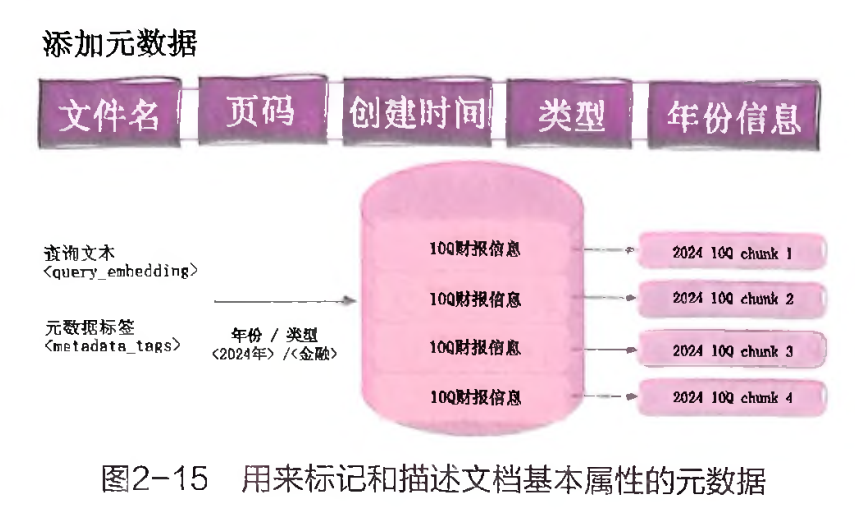

传统的检索（Dense Retrieval）是直接拿用户的问题去库里匹配答案。但问题和答案在语义空间里往往不对等（问题很短，答案很长）。

__HyDE 的做法是：__

1. 生成假设文档：接收到用户问题（例如：“齐天大圣为什么被封印？”）后，先让 LLM（比如千问）凭空写一篇“假答案”。

2. 向量化：将这个“假答案”转化成向量。

3. 相似度检索：用这个“假答案”的向量去知识库里找长得最像的真文档。

__为什么这有效？__
因为“假答案”和“真答案”都是陈述句，它们在语义空间中的距离比“问题”和“答案”要近得多。